# Sentiment Analysis of IMDb Movie Reviews Using Apache Spark and Neural Networks

the main goal of this notebook is use Spark and Neural Networks to analyse movie reviews using a dataset from IMDb.

## Importing and installing necessary items/packages

In [2]:
%pip install -q pyspark scikit-learn pandas numpy matplotlib scipy

In [3]:

import os
import re
import time
import tarfile
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix

from pyspark.sql import SparkSession
from pyspark.sql.functions import lit
from pyspark.ml import Pipeline
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, HashingTF, IDF

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Starting Apache

In [4]:

spark = (
    SparkSession.builder
    .appName("IMDb-Sentiment-Spark-MLP")
    .config("spark.sql.shuffle.partitions", "4")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print("Spark version:", spark.version)
print("Default parallelism:", spark.sparkContext.defaultParallelism)


Spark version: 4.0.4
Default parallelism: 2


## Upload the dataset
The dataset contains 50,000 labelled movie reviews:
- 25,000 training reviews
- 25,000 test reviews
- balanced positive and negative classes
- neutral reviews excluded

I'm having issues with Anaconda, so I'm using Google Collab for this demo (this is why i'm not using the dataset locally.

In [5]:

DATA_URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
ARCHIVE = "aclImdb_v1.tar.gz"
DATA_DIR = "aclImdb"

if not os.path.exists(DATA_DIR):
    if not os.path.exists(ARCHIVE):
        print("Downloading IMDb dataset...")
        urllib.request.urlretrieve(DATA_URL, ARCHIVE)
    print("Extracting dataset...")
    with tarfile.open(ARCHIVE, "r:gz") as tar:
        tar.extractall(".")
else:
    print("Dataset already available.")

print("Dataset path:", os.path.abspath(DATA_DIR))


Extracting dataset...
Dataset path: /content/aclImdb


## Load the train/test with Spark

In [6]:

def load_imdb_split(split_name):
    pos_path = f"{DATA_DIR}/{split_name}/pos/*.txt"
    neg_path = f"{DATA_DIR}/{split_name}/neg/*.txt"

    pos = spark.read.text(pos_path, wholetext=True).withColumn("label", lit(1))
    neg = spark.read.text(neg_path, wholetext=True).withColumn("label", lit(0))

    return pos.unionByName(neg).withColumnRenamed("value", "text")

train_df = load_imdb_split("train").cache()
test_df = load_imdb_split("test").cache()

print("Training rows:", train_df.count())
print("Test rows:", test_df.count())

print("\nTraining class distribution:")
train_df.groupBy("label").count().orderBy("label").show()

print("Test class distribution:")
test_df.groupBy("label").count().orderBy("label").show()


Training rows: 25000
Test rows: 25000

Training class distribution:
+-----+-----+
|label|count|
+-----+-----+
|    0|12500|
|    1|12500|
+-----+-----+

Test class distribution:
+-----+-----+
|label|count|
+-----+-----+
|    0|12500|
|    1|12500|
+-----+-----+



### The step above took a while to process. About 15 minutes

## Spark text-preprocessing and TF-IDF pipeline
The following distributed pipeline is fitted only on the training data to avoid information leakage.
Steps:
1. Tokenisation
2. Stop-word removal
3. HashingTF feature generation
4. Inverse Document Frequency (IDF) weighting

NUM_FEATURES = 2000 keeps the neural-network experiment computationally manageable while still providing a reasonably large text representation.

In [7]:

NUM_FEATURES = 2000

tokenizer = RegexTokenizer(
    inputCol="text",
    outputCol="tokens",
    pattern=r"\W+",
    minTokenLength=2,
    toLowercase=True
)

stopwords = StopWordsRemover(
    inputCol="tokens",
    outputCol="filtered_tokens"
)

tf = HashingTF(
    inputCol="filtered_tokens",
    outputCol="tf_features",
    numFeatures=NUM_FEATURES
)

idf = IDF(
    inputCol="tf_features",
    outputCol="features"
)

text_pipeline = Pipeline(stages=[tokenizer, stopwords, tf, idf])

start = time.perf_counter()
pipeline_model = text_pipeline.fit(train_df)
train_features_df = pipeline_model.transform(train_df).select("features", "label").cache()
test_features_df = pipeline_model.transform(test_df).select("features", "label").cache()

# materialise cached transformations
train_features_df.count()
test_features_df.count()

spark_preprocess_seconds = time.perf_counter() - start
print(f"Spark preprocessing time: {spark_preprocess_seconds:.2f} seconds")


Spark preprocessing time: 78.66 seconds


## Convert Spark vectors to SciPy sparse matrices
Spark performs the distributed text-processing stage.
For neural-network training, the resulting sparse TF-IDF vectors are transferred into a SciPy CSR matrix.


In [8]:

def spark_vectors_to_csr(df, n_features):
    rows = df.collect()

    data = []
    indices = []
    indptr = [0]
    labels = []

    for row in rows:
        vec = row["features"]

        if hasattr(vec, "indices"):  # Spark SparseVector
            data.extend(vec.values)
            indices.extend(vec.indices)
        else:  # DenseVector fallback
            arr = np.asarray(vec)
            nz = np.nonzero(arr)[0]
            data.extend(arr[nz])
            indices.extend(nz)

        indptr.append(len(data))
        labels.append(int(row["label"]))

    X = csr_matrix(
        (np.asarray(data, dtype=np.float32),
         np.asarray(indices, dtype=np.int32),
         np.asarray(indptr, dtype=np.int32)),
        shape=(len(rows), n_features)
    )

    y = np.asarray(labels, dtype=np.int32)
    return X, y


X_train, y_train = spark_vectors_to_csr(train_features_df, NUM_FEATURES)
X_test, y_test = spark_vectors_to_csr(test_features_df, NUM_FEATURES)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Training density:", round(X_train.nnz / (X_train.shape[0] * X_train.shape[1]), 4))


X_train: (25000, 2000)
X_test: (25000, 2000)
Training density: 0.0481


## Neural-network experiments
To demonstrate an iterative experimental approach, three MLP configurations are tested.
### Model 1 — Simple baseline
- one hidden layer
- 64 neurons
- low L2 regularisation
### Model 2 — Increased capacity
- two hidden layers
- 128 and 64 neurons
### Model 3 — Increased capacity + stronger regularisation
- two hidden layers
- stronger L2 penalty (alpha)
This allows us to evaluate whether adding complexity improves generalisation or simply increases training cost / overfitting risk.

In [9]:

EXPERIMENTS = [
    {
        "name": "Model 1 - Baseline",
        "hidden_layer_sizes": (64,),
        "alpha": 0.0001,
    },
    {
        "name": "Model 2 - Deeper",
        "hidden_layer_sizes": (128, 64),
        "alpha": 0.0001,
    },
    {
        "name": "Model 3 - Regularised",
        "hidden_layer_sizes": (128, 64),
        "alpha": 0.001,
    },
]

results = []
trained_models = {}

for exp in EXPERIMENTS:
    print("\n" + "=" * 70)
    print(exp["name"])
    print("=" * 70)

    model = MLPClassifier(
        hidden_layer_sizes=exp["hidden_layer_sizes"],
        activation="relu",
        solver="adam",
        alpha=exp["alpha"],
        batch_size=128,
        learning_rate_init=0.001,
        max_iter=20,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=3,
        random_state=RANDOM_STATE,
        verbose=False,
    )

    start = time.perf_counter()
    model.fit(X_train, y_train)
    train_seconds = time.perf_counter() - start

    y_pred = model.predict(X_test)

    metrics = {
        "Model": exp["name"],
        "Hidden Layers": str(exp["hidden_layer_sizes"]),
        "Alpha": exp["alpha"],
        "Iterations": model.n_iter_,
        "Training Time (s)": train_seconds,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
    }

    results.append(metrics)
    trained_models[exp["name"]] = (model, y_pred)

results_df = pd.DataFrame(results)
results_df



Model 1 - Baseline

Model 2 - Deeper

Model 3 - Regularised


,Model,Hidden Layers,Alpha,Iterations,Training Time (s),Accuracy,Precision,Recall,F1
0,Model 1 - Baseline,"(64,)",0.0001,6,3.386784,0.81372,0.816684,0.80904,0.812844
1,Model 2 - Deeper,"(128, 64)",0.0001,6,9.359503,0.81376,0.810678,0.81872,0.814679
2,Model 3 - Regularised,"(128, 64)",0.0010,5,8.895251,0.81580,0.819403,0.81016,0.814755


## Compare experimental results

In [10]:

display_cols = [
    "Model", "Hidden Layers", "Alpha", "Iterations",
    "Training Time (s)", "Accuracy", "Precision", "Recall", "F1"
]

formatted_results = results_df[display_cols].copy()

for col in ["Accuracy", "Precision", "Recall", "F1"]:
    formatted_results[col] = formatted_results[col].map(lambda x: f"{x:.4f}")

formatted_results["Training Time (s)"] = formatted_results["Training Time (s)"].map(lambda x: f"{x:.2f}")

formatted_results


,Model,Hidden Layers,Alpha,Iterations,Training Time (s),Accuracy,Precision,Recall,F1
0,Model 1 - Baseline,"(64,)",0.0001,6,3.39,0.8137,0.8167,0.8090,0.8128
1,Model 2 - Deeper,"(128, 64)",0.0001,6,9.36,0.8138,0.8107,0.8187,0.8147
2,Model 3 - Regularised,"(128, 64)",0.0010,5,8.90,0.8158,0.8194,0.8102,0.8148


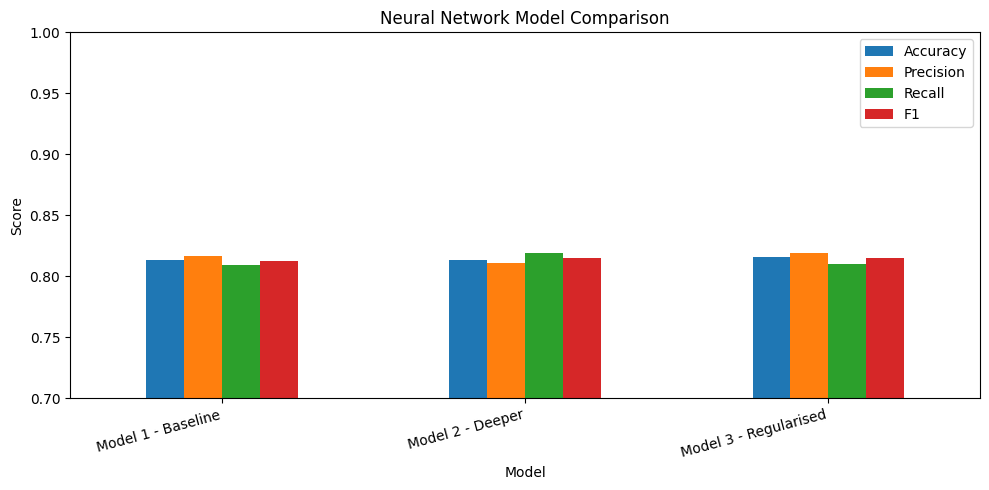

In [11]:

plot_df = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1"]]

ax = plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_ylim(0.7, 1.0)
ax.set_ylabel("Score")
ax.set_title("Neural Network Model Comparison")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


## Confusion matrix for the best model

Best model by F1-score: Model 3 - Regularised


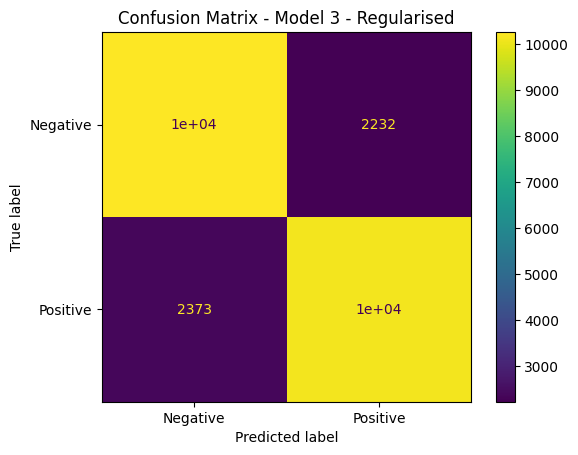

In [12]:

best_row = results_df.sort_values("F1", ascending=False).iloc[0]
best_model_name = best_row["Model"]
best_model, best_pred = trained_models[best_model_name]

print("Best model by F1-score:", best_model_name)

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


## Training-loss behaviour

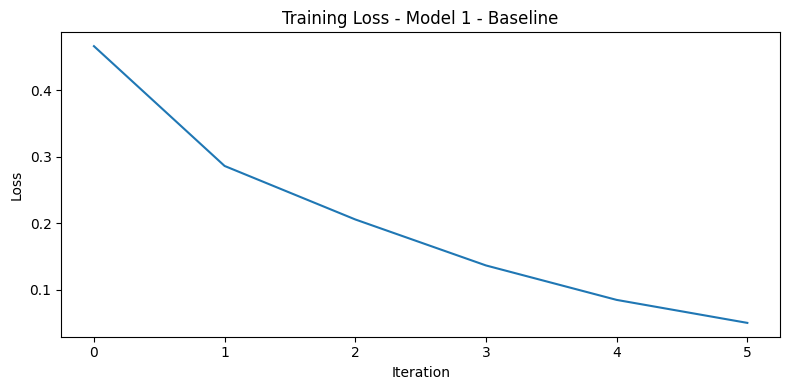

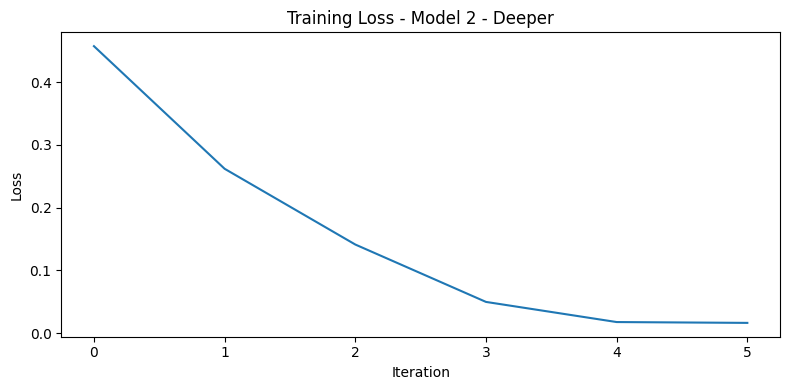

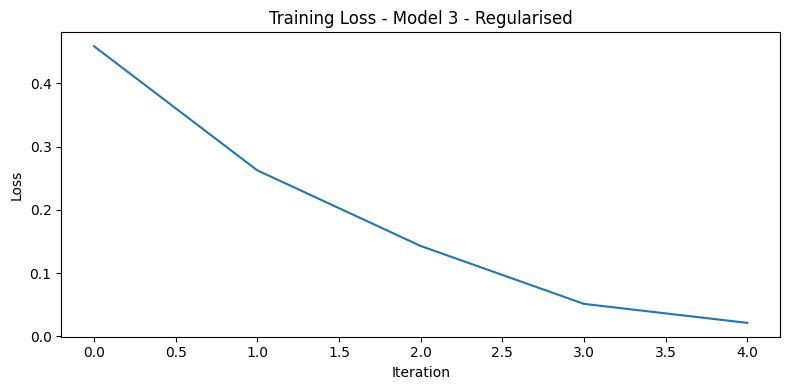

In [13]:

for name, (model, _) in trained_models.items():
    plt.figure(figsize=(8, 4))
    plt.plot(model.loss_curve_)
    plt.title(f"Training Loss - {name}")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.tight_layout()
    plt.show()


## Export results for the report
This step was used to retrieve the results in a csv file, for easier utilization in the report, if necessary.

In [14]:

results_df.to_csv("neural_network_results.csv", index=False)

if "scale_df" in globals():
    scale_df.to_csv("spark_scalability_results.csv", index=False)

print("Saved:")
print("- neural_network_results.csv")
if "scale_df" in globals():
    print("- spark_scalability_results.csv")


Saved:
- neural_network_results.csv


In [15]:
from google.colab import files

files.download("/content/neural_network_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

The experiments showed relatively similar classification performance across the three neural network configurations. The baseline model achieved an accuracy of approximately 81.37%, while the deeper network produced only a marginal improvement despite requiring considerably more training time. The regularised model obtained the best overall performance, reaching 81.58% accuracy and an F1-score of 81.48%. These results suggest that increasing network complexity alone did not substantially improve classification performance, while stronger regularisation provided a small improvement in generalisation.